<a href="https://colab.research.google.com/github/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/blob/main/WHSAT_updatedknowledgegraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!python -m spacy download en_core_web_trf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 1.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import os
import json
import numpy as np
import pandas as pd
import networkx as nx
import spacy
from spacy.matcher import PhraseMatcher

# -------------------------
# Load original dataset
# -------------------------
df = pd.read_csv(
    "https://raw.githubusercontent.com/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/main/cleaned_safety_data_set_A.csv"
)
df = df[["description","severity"]].dropna()

# -------------------------
# Load Bayesian outputs
# -------------------------
drive.mount('/content/drive', force_remount=True)
SAVE_DIR="/content/drive/MyDrive/WHSAT"

mean_probs=np.load(os.path.join(SAVE_DIR,"bayesian_mean_probs.npy"))
std_probs=np.load(os.path.join(SAVE_DIR,"bayesian_std_probs.npy"))
test_idx=np.load(os.path.join(SAVE_DIR,"test_indices.npy"))

test_df=df.iloc[test_idx].copy()
test_df["predicted_severity"]=mean_probs.argmax(axis=1)+1
test_df["uncertainty"]=std_probs.mean(axis=1)

# -------------------------
# NLP
# -------------------------
nlp=spacy.load("en_core_web_trf")
matcher=PhraseMatcher(nlp.vocab,attr="LOWER")

DICTS={
"TASK":["welding","cutting","lifting","maintenance","inspection","drilling"],
"EQUIPMENT":["ladder","forklift","crane","scaffold","machine"],
"HAZARD":["fall","fire","slip","electric shock","collision"],
"PPE":["helmet","gloves","harness","respirator","goggles"],
"CONTROL":["guardrail","permit","lockout","training"]
}

for label,terms in DICTS.items():
    matcher.add(label,[nlp.make_doc(t) for t in terms])

def extract_entities(text):
    doc=nlp(text)
    ents={k:set() for k in DICTS}
    for mid,s,e in matcher(doc):
        label=nlp.vocab.strings[mid]
        ents[label].add(doc[s:e].text.lower())
    return ents

# -------------------------
# Graph
# -------------------------
G=nx.MultiDiGraph()

for idx,row in test_df.iterrows():
    inc=f"incident_{idx}"
    G.add_node(inc,
               type="Incident",
               severity=int(row["severity"]),
               predicted=int(row["predicted_severity"]),
               uncertainty=float(row["uncertainty"]))
    entities=extract_entities(row["description"])
    for etype,vals in entities.items():
        for v in vals:
            node=f"{etype}:{v}"
            G.add_node(node,type=etype)
            G.add_edge(inc,node,relation="contains")

            if etype=="HAZARD":
                sev=f"Severity:{int(row['predicted_severity'])}"
                G.add_node(sev,type="Severity")
                G.add_edge(node,sev,relation="associated_with")

# -------------------------
# Graph metrics
# -------------------------
deg=nx.degree_centrality(G)
bet=nx.betweenness_centrality(nx.Graph(G))
close=nx.closeness_centrality(nx.Graph(G))

metrics=[]
for n in G.nodes():
    metrics.append({
        "node":n,
        "degree":deg.get(n,0),
        "betweenness":bet.get(n,0),
        "closeness":close.get(n,0)
    })

pd.DataFrame(metrics).to_csv("graph_metrics.csv",index=False)

# -------------------------
# Rule engine
# -------------------------
rules=[]
for idx,row in test_df.iterrows():
    e=extract_entities(row["description"])
    rec=[]
    if "fall" in e["HAZARD"] and "harness" not in e["PPE"]:
        rec.append("Use safety harness")
    if "fire" in e["HAZARD"]:
        rec.append("Provide fire extinguisher")
    if "electric shock" in e["HAZARD"]:
        rec.append("Use insulated gloves")
    rules.append({
        "incident":idx,
        "recommendations":"; ".join(rec)
    })

pd.DataFrame(rules).to_csv("recommendations.csv",index=False)

# Export graph
nodes=[{"id":n,**G.nodes[n]} for n in G.nodes()]
edges=[{"source":u,"target":v,**d} for u,v,d in G.edges(data=True)]

pd.DataFrame(nodes).to_csv("kg_nodes.csv",index=False)
pd.DataFrame(edges).to_csv("kg_edges.csv",index=False)

print("Knowledge Graph generated successfully.")


Mounted at /content/drive
Knowledge Graph generated successfully.


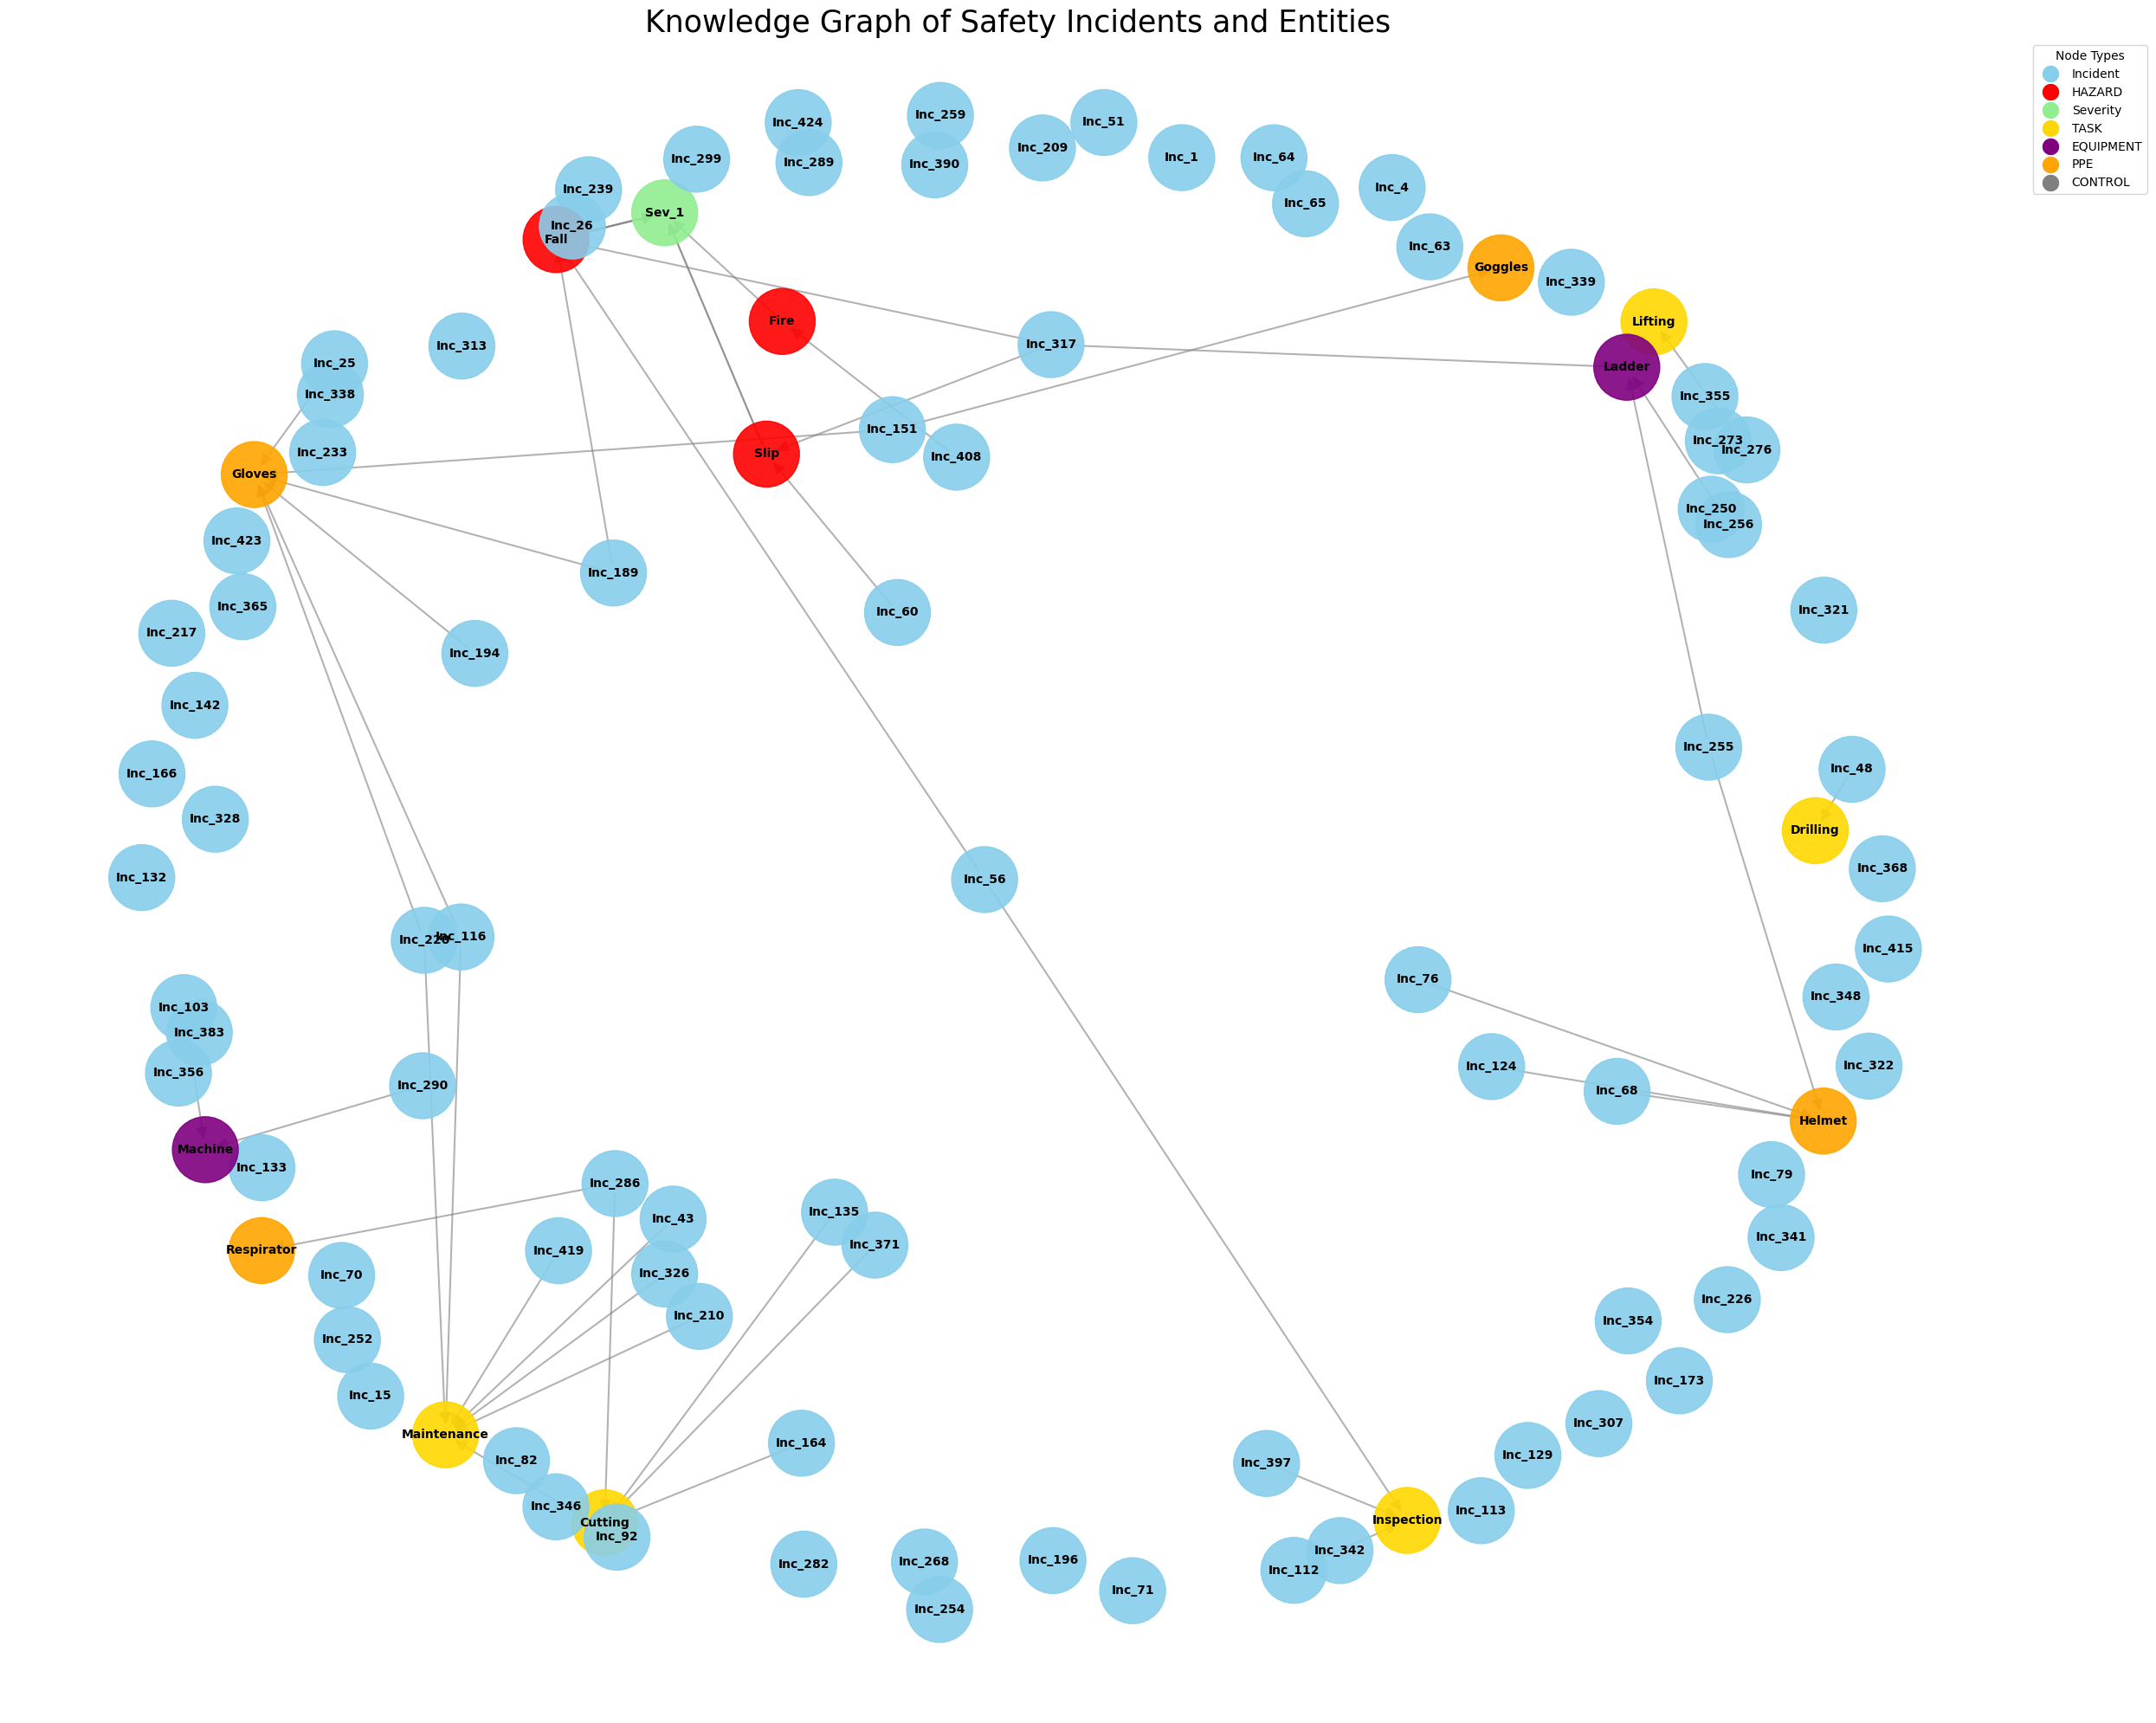

In [8]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Load the nodes and edges from the CSV files
kg_nodes_df = pd.read_csv('kg_nodes.csv')
kg_edges_df = pd.read_csv('kg_edges.csv')

# Reconstruct the graph
KG = nx.MultiDiGraph()

# Add nodes with their attributes
for _, row in kg_nodes_df.iterrows():
    node_id = row['id']
    attributes = row.drop('id').to_dict()
    KG.add_node(node_id, **attributes)

# Add edges with their attributes
for _, row in kg_edges_df.iterrows():
    source = row['source']
    target = row['target']
    attributes = row.drop(['source', 'target']).to_dict()
    KG.add_edge(source, target, **attributes)

# Visualize the graph
plt.figure(figsize=(25, 20)) # Increased figure size
pos = nx.spring_layout(KG, k=0.5, iterations=100, seed=42) # Position nodes more spread out with a fixed seed for reproducibility

# Define node colors based on type and prepare concise labels
node_colors = []
node_labels = {}
color_map = {
    'Incident': 'skyblue',
    'HAZARD': 'red',
    'Severity': 'lightgreen',
    'TASK': 'gold',
    'EQUIPMENT': 'purple',
    'PPE': 'orange',
    'CONTROL': 'gray'
}

for node, data in KG.nodes(data=True):
    node_type = data['type']
    node_colors.append(color_map.get(node_type, 'white')) # Get color from map, default to white

    # Generate more concise labels
    if node_type == 'Incident':
        node_labels[node] = node.replace('incident_', 'Inc_')
    elif node_type == 'Severity':
        node_labels[node] = node.replace('Severity:', 'Sev_')
    else:
        # For HAZARD:fall, TASK:welding, etc., just show the value after the colon
        if ':' in node:
            node_labels[node] = node.split(':')[1].capitalize()
        else:
            node_labels[node] = node # Fallback for nodes without a colon

# Draw nodes
nx.draw_networkx_nodes(KG, pos, node_color=node_colors, node_size=3000, alpha=0.9)

# Draw edges
nx.draw_networkx_edges(KG, pos, edge_color='gray', arrowsize=20, alpha=0.6, width=1.5)

# Draw labels for nodes
nx.draw_networkx_labels(KG, pos, labels=node_labels, font_size=10, font_weight='bold')

plt.title('Knowledge Graph of Safety Incidents and Entities', size=25)
plt.axis('off') # Hide axes

# Create a legend
legend_handles = []
for node_type, color in color_map.items():
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', label=node_type,
                                     markerfacecolor=color, markersize=15))
plt.legend(handles=legend_handles, title="Node Types", loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout() # Adjust layout to prevent legend from being cut off
plt.show()